In [20]:
import numpy as np
import matplotlib.pyplot as plt
import plotly.graph_objects as go
import os

In [33]:
# 1. Himmelblau
def himmelblau(x, y):
    if not (-10 <= x <= 10 and -10 <= y <= 10):
        raise ValueError("x and y must be in [-10, 10] for Himmelblau")
    return (x**2 + y - 11)**2 + (x + y**2 - 7)**2

# 2. Rosenbrock 2D
def rosenbrock_2d(x, y):
    if not (-10 <= x <= 10 and -10 <= y <= 10):
        raise ValueError("x and y must be in [-10, 10] for Rosenbrock")
    return (1 - x)**2 + 100 * (y - x**2)**2

# 3. Rastrigin 2D
def rastrigin_2d(x, y, A=10):
    if not (-5.12 <= x <= 5.12 and -5.12 <= y <= 5.12):
        raise ValueError("x and y must be in [-5.12, 5.12] for Rastrigin")
    return A*2 + (x**2 - A * np.cos(2 * np.pi * x)) + (y**2 - A * np.cos(2 * np.pi * y))

# 4. Sphere 2D
def sphere_2d(x, y):
    if not (-5.12 <= x <= 5.12 and -5.12 <= y <= 5.12):
        raise ValueError("x and y must be in [-5.12, 5.12] for Sphere")
    return x**2 + y**2

# 5. Ackley 2D
def ackley_2d(x, y, a=20, b=0.2, c=2*np.pi):
    if not (-5 <= x <= 5 and -5 <= y <= 5):
        raise ValueError("x and y must be in [-5, 5] for Ackley")
    sum_sq = x**2 + y**2
    sum_cos = np.cos(c * x) + np.cos(c * y)
    return -a * np.exp(-b * np.sqrt(sum_sq / 2)) - np.exp(sum_cos / 2) + a + np.exp(1)

# 6. Levy N.13 2D
def levy_n13_2d(x, y):
    if not (-10 <= x <= 10 and -10 <= y <= 10):
        raise ValueError("x and y must be in [-10, 10] for Levy N.13")
    w1 = 1 + (x - 1)/4
    w2 = 1 + (y - 1)/4
    term1 = np.sin(np.pi * w1)**2
    term2 = ((w1 - 1)**2) * (1 + 10 * np.sin(np.pi * w1 + 1)**2)
    term3 = ((w2 - 1)**2) * (1 + np.sin(2 * np.pi * w2)**2)
    return term1 + term2 + term3


In [45]:
def plot_inline(lims_x, lims_y, function: callable, steps=200, figsize=(8, 8)):
    x = np.linspace(-lims_x, lims_x, steps)
    y = np.linspace(-lims_y, lims_y, steps)
    X, Y = np.meshgrid(x, y)
    
    Z = np.vectorize(function)(X, Y)
    
    fig = plt.figure(figsize=figsize)
    ax = fig.add_subplot(111, projection='3d')

    surf = ax.plot_surface(X, Y, Z, cmap='inferno', edgecolor='none')

    fig.colorbar(surf, shrink=0.5, aspect=10)

    ax.set_title(f'Функция {function.__name__}')
    ax.set_xlabel('X')
    ax.set_ylabel('Y')
    ax.set_zlabel('Z = f(X, Y)')

    plt.show()


def plot_html(lims_x, lims_y, function: callable, steps=200, path='html_graphics'):
    os.makedirs(path, exist_ok=True)

    x = np.linspace(-lims_x, lims_x, steps)
    y = np.linspace(-lims_y, lims_y, steps)
    X, Y = np.meshgrid(x, y)
    Z = np.vectorize(function)(X, Y)

    fig = go.Figure(data=[
        go.Surface(
            x=X,
            y=Y,
            z=Z,
            colorscale='Viridis',
            showscale=True            
        )
    ])

    fig.update_layout(
    title=f'Функция {function.__name__}',
    scene=dict(
        xaxis_title='X',
        yaxis_title='Y',
        zaxis_title='Z = f(X, Y)',
        camera_eye=dict(x=1.5, y=1.5, z=0.8)
    ),
    width=800,
    height=600
    )

    fig.write_html(os.path.join(path, f"{function.__name__}.html"))

# Функция Химмельблау

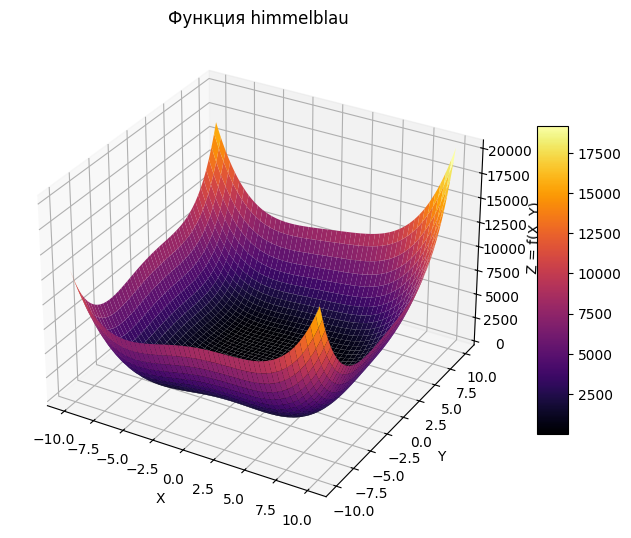

In [46]:
plot_html(10, 10, himmelblau)
plot_inline(10, 10, himmelblau)

# Функция Розенброка

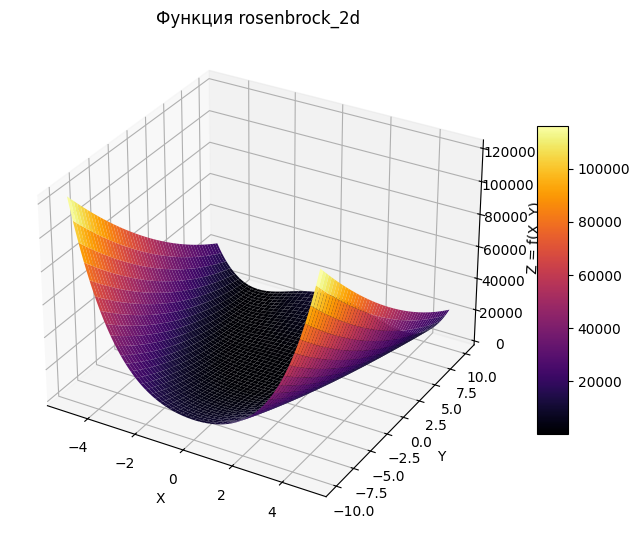

In [47]:
plot_html(10, 10, rosenbrock_2d)
plot_inline(5, 10, rosenbrock_2d)

# Функция Растригина

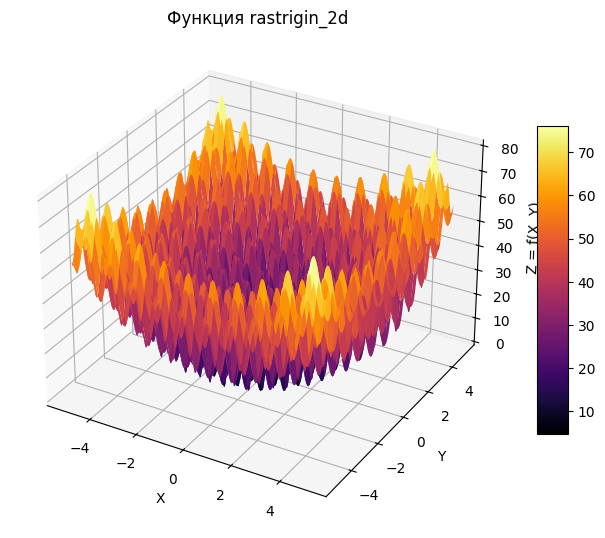

In [49]:
plot_html(5.12, 5.12, rastrigin_2d)
plot_inline(5.12, 5.12, rastrigin_2d)

# Функция Леви N.13 

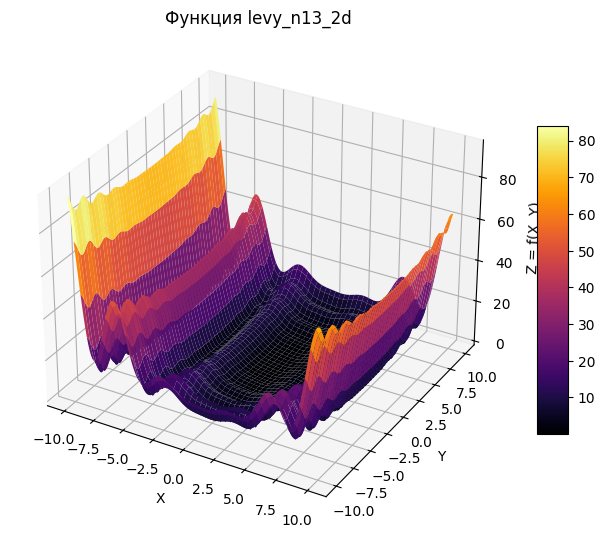

In [50]:
plot_html(10, 10, levy_n13_2d)
plot_inline(10, 10, levy_n13_2d)

# Сферическая функция

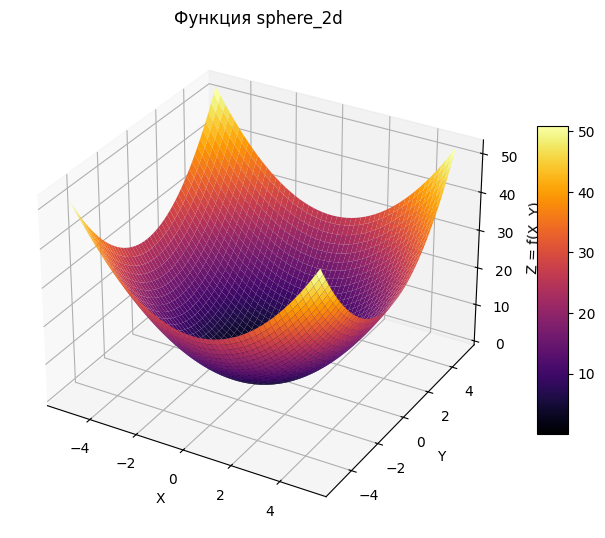

In [52]:
plot_html(5.12, 5.12, sphere_2d)
plot_inline(5.12, 5.12, sphere_2d)

# Функция Акли

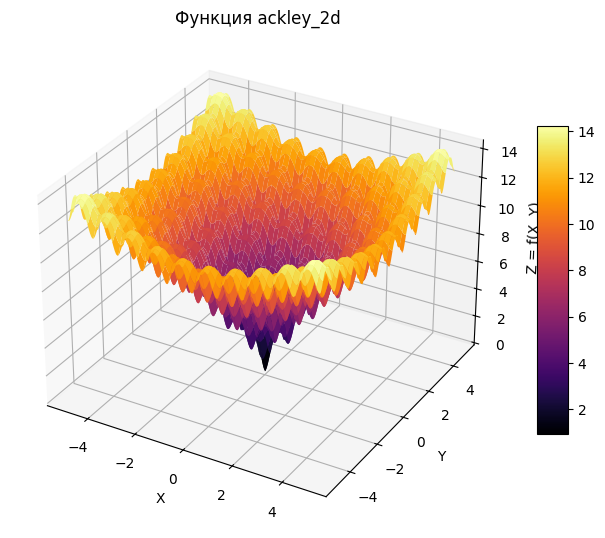

In [53]:
plot_html(5, 5, ackley_2d)
plot_inline(5, 5, ackley_2d)